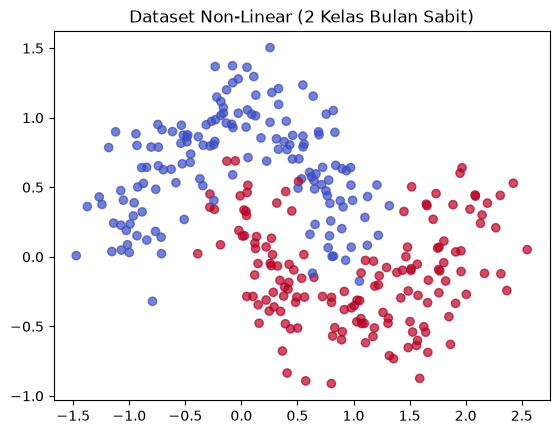

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

Dataset make_moons menghasilkan dua kelas data yang berbentuk bulan sabit dan saling bertautan. Pola tersebut menunjukkan bahwa data bersifat non-linear sehingga tidak dapat dipisahkan secara optimal menggunakan satu garis lurus. Oleh karena itu, diperlukan model yang mampu mempelajari hubungan non-linear seperti Neural Network.

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
 metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30,
 validation_split=0.2, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.917


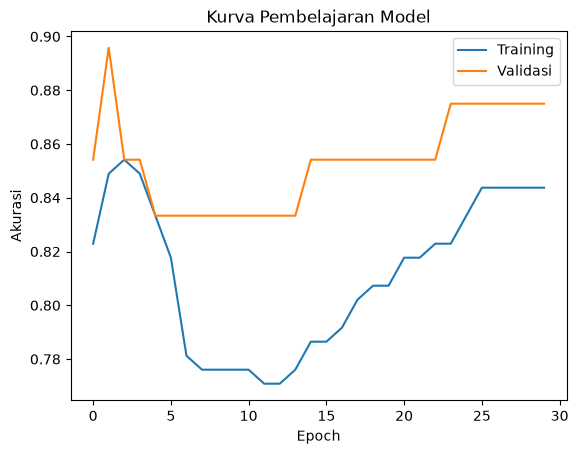

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

Berdasarkan kurva pembelajaran, akurasi training dan validasi tidak menunjukkan pola yang saling menjauh secara signifikan. Akurasi validasi cenderung stabil dan bahkan meningkat pada beberapa epoch terakhir, sementara akurasi training juga mengalami peningkatan setelah sempat menurun. Hal ini menunjukkan bahwa model tidak mengalami indikasi overfitting yang kuat dan masih mampu melakukan generalisasi dengan cukup baik. Hal tersebut juga didukung oleh akurasi pada data uji sebesar 91,7%, yang menunjukkan bahwa Neural Network mampu mempelajari pola non-linear pada dataset make_moons dengan baik.

In [6]:
ulasan = [
    # Positif
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas produk sangat bagus dan memuaskan',
    'Sangat puas, akan beli lagi',
    'Pelayanan sangat ramah dan cepat',
    'Produk sesuai dengan deskripsi',
    'Recommended, harga sesuai kualitas',
    'Barang sampai dengan aman dan cepat',
    'Kualitasnya bagus, saya sangat puas',
    'Produknya keren dan berkualitas',
    'Pengiriman cepat dan barang bagus',
    'Saya suka sekali dengan produk ini',
    'Pelayanannya sangat memuaskan',
    'Harga murah tetapi kualitas bagus',
    'Barang sesuai pesanan dan tidak mengecewakan',
    'Sangat recommended untuk dibeli',
    'Produk berkualitas dan tahan lama',
    'Pengiriman cepat dan pelayanan baik',
    'Saya puas dengan pembelian ini',
    'Barang bagus dan sesuai ekspektasi',
    'Kualitas produk sangat memuaskan',

    # Negatif
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pengiriman sangat lambat dan mengecewakan',
    'Barang yang datang rusak',
    'Kualitas produk sangat buruk',
    'Saya kecewa dengan produk ini',
    'Barang tidak sesuai dengan pesanan',
    'Pelayanan sangat buruk dan lambat',
    'Produk tidak sesuai deskripsi',
    'Barang rusak ketika diterima',
    'Harganya mahal tetapi kualitas buruk',
    'Pengiriman terlambat dan barang rusak',
    'Saya tidak puas dengan pembelian ini',
    'Produk mengecewakan dan tidak berkualitas',
    'Barang berbeda dengan gambar',
    'Pelayanan tidak ramah dan mengecewakan',
    'Kualitas sangat buruk dan tidak tahan lama',
    'Produk tidak sesuai ekspektasi',
    'Sangat kecewa dengan pembelian ini'
]

label = [
    # Positif = 1
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

    # Negatif = 0
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 60
['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'beli'
 'berbeda' 'berkualitas']


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
 X_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.750
Positif


Berdasarkan hasil pengujian, model klasifikasi sentimen memperoleh akurasi sebesar 75%. Hal ini menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data uji dengan benar. Ketika diberikan kalimat baru berupa “Pelayanan sangat memuaskan dan ramah”, model memprediksi kalimat tersebut sebagai sentimen positif. Hasil tersebut sesuai dengan makna kalimat karena terdapat kata-kata yang menunjukkan kepuasan dan pelayanan yang baik. Namun, karena dataset yang digunakan relatif kecil, hasil akurasi belum dapat menggambarkan performa model secara umum dan masih dapat ditingkatkan dengan menggunakan dataset yang lebih besar dan bervariasi.